In [5]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from datetime import datetime
from tqdm import tqdm

### Parameters

In [ ]:
# Strategy Parameters
horizon_days = 30       # Forward return horizon for target and holding period
decile_threshold = 0.9  # Top 10% (0.9)
min_train_samples = 500 # Minimum total samples to start walk-forward
min_sym_train = 100     # Minimum samples per symbol to train a model
training_lookback = 365 # Max days of history to use for training (None for all history)
n_tranches = 4          # Number of staggered tranches
tx_fee = 0.002          # 0.2% entry, 0.2% exit = 0.4% total per rotation
backtest_months = 1     # Number of months to backtest (for fast dev)

### Data Loading and Feature Engineering

In [6]:
df = pl.read_parquet('polarity/data/*.parquet').rename({'asset': 'symbol'})
df = df.sort(['symbol', 'timestamp'])

# Targets and Features
df = df.with_columns([
    pl.col('price').log().diff().over('symbol').alias('log_return'),
    pl.col('price').log().diff().over('symbol').rolling_sum(window_size=horizon_days).shift(-horizon_days).over('symbol').alias('target')
])

# Derive features
df = df.with_columns([
    ((pl.col('tcicv') - pl.col('price')) / pl.col('price')).alias('tcid'),
    ((pl.col('mdccv') - pl.col('price')) / pl.col('price')).alias('mdcd')
])

# First Derivatives: 1-week change
deriv_cols = ['udpil', 'udpis', 'udpim', 'tci', 'mdccv', 'upprob']
df = df.with_columns([pl.col(c).diff(7).over('symbol').alias(f'{c}_d1') for c in deriv_cols])

z_window = 30
def rolling_zscore(column, window):
    return (pl.col(column) - pl.col(column).rolling_mean(window)) / pl.col(column).rolling_std(window)

df = df.with_columns([
    rolling_zscore('tcid', z_window).over('symbol').alias('tcid_z'),
    rolling_zscore('mdcd', z_window).over('symbol').alias('mdcd_z'),
    rolling_zscore('upprob', z_window).over('symbol').alias('upprob_z')
])

features = ['upprob_z', 'mdcd_z', 'tcid_z', 'mbi', 'udpil', 'udpis', 'udpim', 'tci'] + [f'{c}_d1' for c in deriv_cols]
df = df.drop_nulls(subset=['tcid_z', 'mdcd_z', 'upprob_z', 'target'] + [f'{c}_d1' for c in deriv_cols])

# BTC Benchmark
btc_returns = df.filter(pl.col('symbol') == 'btc').select(['timestamp', 'log_return']).rename({'log_return': 'btc_return'})

In [7]:
def compute_metrics(returns, benchmark_rets=None):
    if len(returns) == 0: return {"Return": 0, "Sharpe": 0, "MaxDD": 0, "IR": 0}
    ann_return = returns.mean() * 365
    ann_std = returns.std() * np.sqrt(365)
    sharpe = ann_return / ann_std if ann_std != 0 else 0
    cum_returns = returns.cum_sum().exp()
    rolling_max = cum_returns.cum_max()
    drawdown = (cum_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()
    ir = 0
    if benchmark_rets is not None:
        active_return = returns - benchmark_rets
        ir = (active_return.mean() * 365) / (active_return.std() * np.sqrt(365)) if active_return.std() != 0 else 0
    return {"Return": ann_return, "Sharpe": sharpe, "MaxDD": max_dd, "IR": ir}

### Simplified Staggered Weekly Walk-Forward

Starting Walk-Forward Portfolio Construction Comparison...


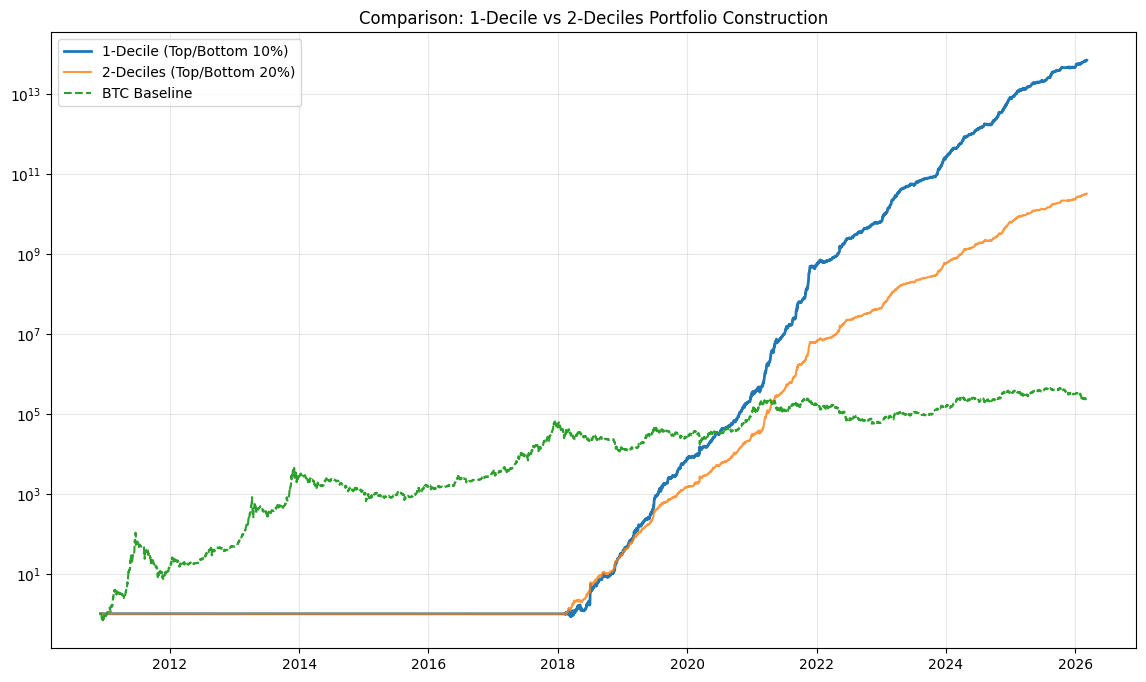


Performance Comparison Table:
Scenario   Return   Sharpe       IR     MaxDD
1-Decile 2.090236 3.955224 1.201457 -0.324810
2-Decile 1.586435 4.438668 0.784965 -0.173722
     BTC 0.813567 0.922402 0.000000 -0.930744


In [8]:
all_dates = df['timestamp'].unique().sort()

# Filter dates for the simulation to start early enough to fill tranches
if backtest_months:
    bt_start_date = all_dates.max() - pd.DateOffset(months=backtest_months)
    # Start simulation 1 horizon + 1 week early to ensure tranches are populated
    sim_start_date = bt_start_date - pd.Timedelta(days=horizon_days + 8)
    simulation_dates = all_dates.filter(all_dates >= sim_start_date)
    print(f"Backtest will record results from: {bt_start_date}")
    print(f"Simulation starts at: {sim_start_date} to warm up tranches.")
else:
    bt_start_date = all_dates.min()
    simulation_dates = all_dates

fridays = df.select(pl.col('timestamp').unique().sort()).filter(pl.col('timestamp').dt.weekday() == 5)['timestamp'].to_list()

tranches = [None] * n_tranches
daily_records = []

print(f"Starting Walk-Forward: Horizon={horizon_days}d, TopDecile={decile_threshold}, TrainLookback={training_lookback}d")

for d in tqdm(simulation_dates):
    # 1. Capture today's returns for existing tranches (T+1 logic)
    day_data = df.filter(pl.col('timestamp') == d)
    day_rets_dict = dict(zip(day_data['symbol'], day_data['log_return']))
    
    tranche_rets = []
    for t in tranches:
        if t is not None:
            l_rets = [day_rets_dict.get(s, 0) for s in t]
            tranche_rets.append(np.mean(l_rets) if l_rets else 0)
    
    if tranche_rets:
        avg_ret = sum(tranche_rets) / n_tranches
        if d in fridays:
            avg_ret += np.log(1 - (tx_fee * 2) * (1/n_tranches)) # Entry + Exit fee on rotated slice
        
        # ONLY record if we are within the backtest window
        if d >= bt_start_date:
            daily_records.append({'timestamp': d, 'port_ret': avg_ret})

    # 2. Rebalance (Update tranches after capturing today's returns)
    if d in fridays:
        week_idx = fridays.index(d)
        tranche_idx = week_idx % n_tranches
        
        # Training data strictly before d
        t_cutoff = d
        t_start = (d - pd.Timedelta(days=training_lookback)) if training_lookback else all_dates.min()
        train_pool = df.filter((pl.col('timestamp') < t_cutoff) & (pl.col('timestamp') >= t_start))
        
        symbols_at_close = day_data['symbol'].unique().to_list()
        
        if train_pool.height > min_train_samples and len(symbols_at_close) >= 10:
            preds = []
            for sym in symbols_at_close:
                sym_train = train_pool.filter(pl.col('symbol') == sym)
                if sym_train.height < min_sym_train: continue
                
                # Combined Model logic
                X_train, y_train = sym_train[features].to_pandas(), sym_train['target'].to_pandas()
                model_lin = LinearRegression().fit(X_train, y_train)
                residuals = y_train - model_lin.predict(X_train)
                model_xgb = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=-1).fit(X_train, residuals)
                
                # Predict using close signals of d
                current_features = day_data.filter(pl.col('symbol') == sym)[features]
                if current_features.height == 0: continue
                X_test = current_features.to_pandas()
                final_pred = model_lin.predict(X_test)[0] + model_xgb.predict(X_test)[0]
                preds.append({'symbol': sym, 'pred': final_pred})
            
            if preds:
                pdf = pd.DataFrame(preds)
                pdf['rank'] = pdf['pred'].rank(pct=True)
                # Long only top decile with positive prediction
                tranches[tranche_idx] = pdf[(pdf['rank'] >= decile_threshold) & (pdf['pred'] > 0)]['symbol'].tolist()

### Final Results

In [ ]:
res_df = pd.DataFrame(daily_records).set_index('timestamp')
res_df = res_df.join(btc_returns.to_pandas().set_index('timestamp'), how='left')
res_df['cum_strat'] = res_df['port_ret'].cumsum().apply(np.exp)
res_df['cum_btc'] = res_df['btc_return'].cumsum().apply(np.exp)

plt.figure(figsize=(12, 6))
plt.plot(res_df.index, res_df['cum_strat'], label='Staggered Strategy (Long Only)')
plt.plot(res_df.index, res_df['cum_btc'], label='BTC Baseline', linestyle='--')
plt.yscale('log'); plt.title('Simplified Strategy Cumulative Returns'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

m = compute_metrics(pl.from_pandas(res_df.reset_index())['port_ret'], pl.from_pandas(res_df.reset_index())['btc_return'])
print("\nFinal Performance Metrics:")
for k, v in m.items(): print(f"{k}: {v:.4f}")